In [26]:
import json, os

kaggle_dict = {
    "username": "sawankharte111",
    "key": "KGAT_682c04a3fcee2dae5c508891aac543aa"
}

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("kaggle.json created successfully")

kaggle.json created successfully


In [27]:
!kaggle datasets list | head

ref                                                            title                                               size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
saidaminsaidaxmadov/chocolate-sales                            Chocolate Sales                                   468320  2026-01-04 14:23:35.490000          14960        264  1.0              
aliiihussain/amazon-sales-dataset                              Amazon_Sales_Dataset                             1297759  2026-02-01 11:37:12.353000           2327         48  1.0              
hassanjameelahmed/store-sales                                  Retail Store Sales                                 66677  2026-02-04 06:31:47.217000            649         27  1.0              
wardabilal/customer-shopping-behavi

In [28]:
!kaggle datasets download -d raddar/chest-xrays-indiana-university

Dataset URL: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
^C


In [29]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow import keras
from glob import glob
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import KFold
import cv2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Concatenate, Dropout
from tensorflow.keras.layers import Lambda, RepeatVector
from tensorflow.keras.models import Model
import re
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [30]:
df_report = pd.read_csv('indiana_reports.csv')
df_pro = pd.read_csv('indiana_projections.csv')

In [31]:
df_report.shape

(3851, 8)

In [32]:
df_pro.shape

(7466, 3)

In [33]:
df_pro = df_pro.drop_duplicates(subset="uid").reset_index(drop=True)
df_report = df_report.drop_duplicates(subset="uid").reset_index(drop=True)

common_uids = set(df_pro["uid"]).intersection(set(df_report["uid"]))

df_pro = df_pro[df_pro["uid"].isin(common_uids)].sort_values("uid").reset_index(drop=True)
df_report = df_report[df_report["uid"].isin(common_uids)].sort_values("uid").reset_index(drop=True)

print("Images shape =", df_pro.shape)
print("Reports shape =", df_report.shape)

Images shape = (3851, 3)
Reports shape = (3851, 8)


In [36]:
image_path = "images1"
images = (image_path + "*.png")

In [37]:
len(images)

12

In [52]:
import os

IMAGE_ROOT = "images1"
# OR if in Drive:
# IMAGE_ROOT = "/content/drive/MyDrive/iu_xray/images/images_normalized"

print("Total images:", len(os.listdir(IMAGE_ROOT)))
print(os.listdir(IMAGE_ROOT)[:5])

Total images: 256
['77_IM-2315-1001-0001.dcm.png', '46_IM-2090-1001.dcm.png', '52_IM-2131-2001.dcm.png', '51_IM-2125-1001.dcm.png', '14_IM-0256-1001.dcm.png']


In [53]:
import os
from glob import glob

# ===== SET ROOT PATH HERE =====
# Uncomment ONLY ONE

# image_path = "/content/iu_xray/images/images_normalized/"
image_path = "images1"

# =============================

# Safety check
if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image folder not found: {image_path}")

# Collect all PNG images
images = sorted(glob(os.path.join(image_path, "*.png")))

# Final checks
print(f"Image folder: {image_path}")
print(f"Total images found: {len(images)}")
print("First 5 images:")
for img in images[:5]:
    print(img)

Image folder: images1
Total images found: 255
First 5 images:
images1/100_IM-0002-1001.dcm.png
images1/100_IM-0002-2001.dcm.png
images1/101_IM-0011-2001.dcm.png
images1/101_IM-0011-4004.dcm.png
images1/102_IM-0016-1001.dcm.png


In [54]:
len(images)

255

In [55]:
resized_images = []
mean = 0.485
std = 0.229

for img_name in df_pro["filename"]:
    img_path = os.path.join(image_path, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Warning: Image not found - {img_name}")
        continue

    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = (img - mean) / std
    img = np.expand_dims(img, axis=-1)
    resized_images.append(img)

resized_images = np.array(resized_images)
print("Final shape:", resized_images.shape)


Final shape: (132, 224, 224, 1)


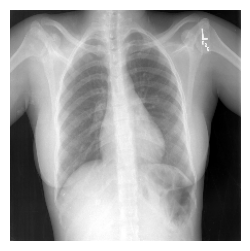

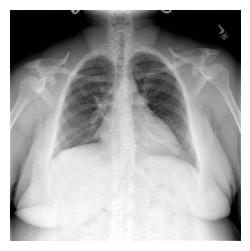

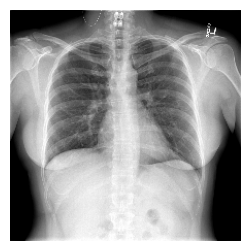

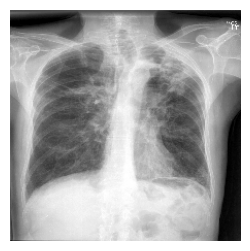

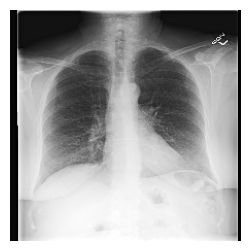

In [56]:
for i in range(5):  # show first 5 images
    plt.figure(figsize=(3,3))
    plt.imshow(resized_images[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()

In [57]:
cnn_encoder = models.Sequential([
    layers.Input(shape=(224, 224, 1)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)), layers.Conv2D(256, (3,3), activation='relu', padding='same'),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)), layers.Conv2D(512, (3,3), activation='relu', padding='same'),

    layers.Conv2D(512, (3,3), activation='relu', padding='same'),
    layers.Conv2D(512, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(512, (3,3), activation='relu', padding='same'),
    layers.Conv2D(512, (3,3), activation='relu', padding='same'),
    layers.Conv2D(512, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)) ])

In [58]:
cnn_encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,713,536 (56.13 MB)

 Trainable params: 14,713,536 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
input_layer = layers.Input(shape=(224, 224, 1))
x = cnn_encoder(input_layer)
x = layers.Reshape((49, 512))(x)

In [60]:
encoder_model = models.Model(inputs=input_layer, outputs=x)
encoder_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 7, 7, 512)      │    14,713,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 49, 512)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,713,536 (56.13 MB)

 Trainable params: 14,713,536 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
encoder_features = encoder_model.predict(resized_images, batch_size=32, verbose=1)
print(encoder_features.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 87s 16s/step
(132, 49, 512)


In [63]:
df_report.shape

(3851, 8)

In [64]:
reports = df_report["findings"].astype(str).tolist()

In [65]:
reports = [r if len(str(r).strip()) > 0 else "no findings" for r in reports]

In [66]:
print("Reports:", len(reports))

Reports: 3851


In [67]:
df_report.isnull().sum()

,0
uid,0
MeSH,0
Problems,0
image,0
indication,86
comparison,1166
findings,514
impression,31


In [68]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s.,]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [69]:
df_report["findings"] = df_report["findings"].astype(str)
df_report["findings"] = df_report["findings"].apply(lambda x: clean_text(x))
df_report["findings"] = df_report["findings"].apply(lambda x: x if len(x.strip()) > 0 else "no findings")

In [70]:
df_report["findings"] = df_report["findings"].apply(lambda x: "<start> " + x + " <end>")

In [71]:
reports = df_report["findings"].tolist()
print("Total reports:", len(reports))

Total reports: 3851


In [72]:
df_report["findings"].isnull().sum()

np.int64(0)

In [73]:
tokenizer_test = Tokenizer(oov_token="<unk>")
tokenizer_test.fit_on_texts(df_report["findings"])

print("Actual unique words in dataset:", len(tokenizer_test.word_index))

Actual unique words in dataset: 1691


In [74]:
vocab_size =2000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<unk>")
tokenizer.fit_on_texts(df_report["findings"])

In [75]:
report_sequences = tokenizer.texts_to_sequences(df_report["findings"])

In [76]:
max_len = 200

In [77]:
# Decoder input = all words except last
decoder_input_data = pad_sequences([seq[:-1] for seq in report_sequences],
                                   maxlen=max_len-1, padding='post')

# Decoder output = all words except first
decoder_output_data = pad_sequences([seq[1:] for seq in report_sequences],
                                    maxlen=max_len-1, padding='post')

# For sparse_categorical_crossentropy
decoder_output_data = np.expand_dims(decoder_output_data, -1)

In [78]:
report_padded = pad_sequences(report_sequences, maxlen=max_len, padding='post', truncating='post')

In [79]:
# prepare decoder unput and output
decoder_input  = report_padded[:, :-1]
decoder_output = report_padded[:, 1:]

In [80]:
encoder_input = layers.Input(shape=(49, 512), name='encoder_input')   # extracted CNN features
decoder_input = layers.Input(shape=(max_len - 1,), name='decoder_input')

In [81]:
embedding = layers.Embedding(input_dim=vocab_size, output_dim=256, mask_zero=True, name='embedding')(decoder_input)

In [82]:
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, encoder_output, hidden_state):
        hidden_state_with_time_axis = tf.expand_dims(hidden_state, 1)
        score = tf.nn.tanh(self.W1(encoder_output) + self.W2(hidden_state_with_time_axis))
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        context_vector = attention_weights * encoder_output
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

In [83]:
# Define encoder and decoder inputs
encoder_input = layers.Input(shape=(49, 512), name='encoder_input')
decoder_input = layers.Input(shape=(max_len - 1,), name='decoder_input')

# Embedding layer for decoder
embedding = layers.Embedding(input_dim=vocab_size, output_dim=256, mask_zero=True, name='embedding')(decoder_input)

# Initialize decoder LSTM
decoder_lstm = layers.LSTM(512, return_sequences=True, return_state=True, name='decoder_lstm')

# Attention layer
attention = BahdanauAttention(256)

# Process decoder step-by-step
# (we use Lambda or custom loop for simplicity demonstration)
def apply_attention(inputs):
    encoder_out, decoder_emb = inputs
    hidden_state = tf.reduce_mean(encoder_out, axis=1)  # dummy hidden state
    attention = BahdanauAttention(512)
    context_vector, attn_weights = attention(encoder_out, hidden_state)

    # Expand and repeat context to match decoder time steps
    context_vector = tf.expand_dims(context_vector, 1)
    context_vector = tf.repeat(context_vector, repeats=tf.shape(decoder_emb)[1], axis=1)

    combined = tf.concat([context_vector, decoder_emb], axis=-1)
    return combined


context_combined = layers.Lambda(apply_attention, output_shape=(max_len - 1, 256 + 512))(
    [encoder_input, embedding]
)

# Pass through decoder LSTM
decoder_outputs, _, _ = decoder_lstm(context_combined)

# Output layer
output = layers.Dense(vocab_size, activation='softmax', name='output')(decoder_outputs)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'lambda' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [84]:
encoder_features = encoder_features.astype('float32')
decoder_input_data = decoder_input_data.astype('int32')
decoder_output_data = decoder_output_data.astype('int32')

In [85]:
# Define number of folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

fold_no = 1
acc_per_fold = []
loss_per_fold = []

for train_index, val_index in kfold.split(encoder_features):
    print(f"\n Training Fold {fold_no} ------------------------------")

    # Split the data for this fold
    X_train_enc, X_val_enc = encoder_features[train_index], encoder_features[val_index]
    X_train_dec_inp, X_val_dec_inp = decoder_input_data[train_index], decoder_input_data[val_index]
    y_train, y_val = decoder_output_data[train_index], decoder_output_data[val_index]

    # Build your model from scratch (important!)
    full_model = models.Model(inputs=[encoder_input, decoder_input], outputs=output)

    full_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train model for this fold
    history = full_model.fit(
        [X_train_enc, X_train_dec_inp], y_train,
        validation_data=([X_val_enc, X_val_dec_inp], y_val),
        epochs=20,
        batch_size=32,
        verbose=1
    )


 Training Fold 1 ------------------------------
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 44s 9s/step - accuracy: 0.4404 - loss: 6.9834 - val_accuracy: 0.8437 - val_loss: 1.7941
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 35s 8s/step - accuracy: 0.8567 - loss: 1.4872 - val_accuracy: 0.8437 - val_loss: 1.5218
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 33s 8s/step - accuracy: 0.8623 - loss: 1.3541 - val_accuracy: 0.8444 - val_loss: 1.5108
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 39s 8s/step - accuracy: 0.8543 - loss: 1.3648 - val_accuracy: 0.8388 - val_loss: 1.3704
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 7s/step - accuracy: 0.8488 - loss: 1.2946 - val_accuracy: 0.8438 - val_loss: 1.3396
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 8s/step - accuracy: 0.8662 - loss: 1.1501 - val_accuracy: 0.8440 - val_loss: 1.2608
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 33s 8s/step - accuracy: 0.8605 - loss: 1.1314 - val_accuracy: 0.8438 - val_loss: 1.2363
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 37s 9s/step - accuracy: 0.8624 - loss: 1.0954 -

In [86]:
def generate_report(img_path, encoder_model, full_model, tokenizer, max_len=200, mean=0.485, std=0.229):
    """
    Robust inference for your trained `full_model`.
    - max_len: the original `max_len` you used (e.g., 200)
    - the model expects decoder_input shape (max_len - 1,)
    """
    import cv2, numpy as np, re
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    # 1) read + preprocess (must match training preprocessing)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Image not found: {img_path}")
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = (img - mean) / std
    img = np.expand_dims(img, axis=[0, -1])  # shape (1,224,224,1), as used for encoder

    # 2) get encoder features (shape (1,49,512) for your encoder)
    enc_feats = encoder_model.predict(img, verbose=0)

    # 3) safe token ids - many tokenizers use different names; try multiple fallbacks
    start_token = (tokenizer.word_index.get('<start>') or
                   tokenizer.word_index.get('startseq') or
                   tokenizer.word_index.get('sos') or
                   tokenizer.word_index.get('start') or
                   1)  # last-resort
    end_token = (tokenizer.word_index.get('<end>') or
                 tokenizer.word_index.get('endseq') or
                 tokenizer.word_index.get('eos') or
                 tokenizer.word_index.get('end') or
                 2)

    # 4) prepare sequence for generation
    decoder_maxlen = max_len - 1  # because you trained decoder with max_len-1
    input_seq = [start_token]
    result_words = []

    for step in range(decoder_maxlen):
        # pad to the SAME length used during training
        dec_inp = pad_sequences([input_seq], maxlen=decoder_maxlen, padding='post')

        # predict full sequence logits; take the logits at the next position index
        preds = full_model.predict([enc_feats, dec_inp], verbose=0)  # shape (1, decoder_maxlen, vocab)
        # next token position is len(input_seq)-1
        pos = len(input_seq) - 1
        if pos >= preds.shape[1]:
            # safety: if position beyond model output, stop
            break
        probs = preds[0, pos]  # (vocab_size,)

        # greedy selection (argmax)
        next_id = int(np.argmax(probs))

        # stop if end token
        if next_id == end_token:
            break

        # skip padding and the start token
        if next_id == 0 or next_id == start_token:
            # if model outputs pad/start, try to continue (but avoid infinite loop)
            # append a small safeguard; here we skip appending and continue
            input_seq.append(next_id)
            continue

        word = tokenizer.index_word.get(next_id, "")
        if word:
            result_words.append(word)
        input_seq.append(next_id)

    # 5) format and clean
    if not result_words:
        return "Findings:\n Unable to generate report."

    report = " ".join(result_words)
    # Only remove token markers like <unk>, <start>, <end>; avoid removing legitimate words
    report = re.sub(r"(<unk>|<start>|<end>)", " ", report)
    report = re.sub(r"\s+", " ", report).strip()
    if not report.endswith("."):
        report += "."

    # Capitalize first char
    report = report[0].upper() + report[1:]

    return "Findings:\n" + report

In [93]:
generated = generate_report(
    "264_IM-1125-1001.dcm.png",
    encoder_model,  # your encoder model object
    full_model,     # the trained fold model you want to use for inference
    tokenizer,
    max_len=200
)
print(generated)

Findings:
The heart is normal in size the mediastinum is unremarkable xxxx xxxx opacities in right mid lung the lungs are otherwise grossly clear.


In [89]:
encoder_model.save("encoder_model.keras")
full_model.save("full_model.keras")

In [90]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)